In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
c=pd.read_csv('customer_churn.csv')

In [3]:
c.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [4]:
c


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [5]:
c.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [6]:
c.nunique()

age                       52
income                   932
credit_score             950
transactions_month        34
avg_purchase_value       950
days_since_last_login    350
tenure_months            119
num_products               5
gender                     2
region                     4
churn                      2
dtype: int64

In [7]:
c.columns

Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'gender', 'region', 'churn'],
      dtype='object')

In [8]:
#check value count for target variable
c['churn'].value_counts()


churn
1    517
0    483
Name: count, dtype: int64

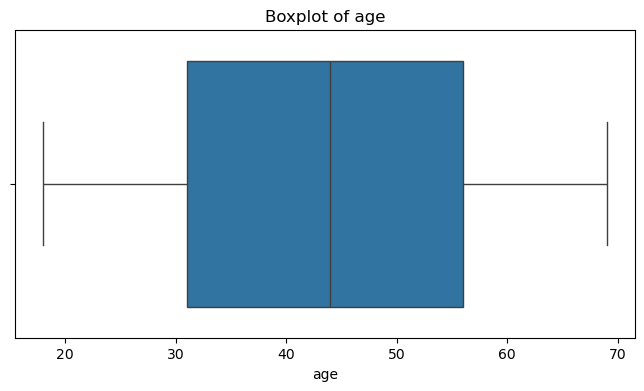

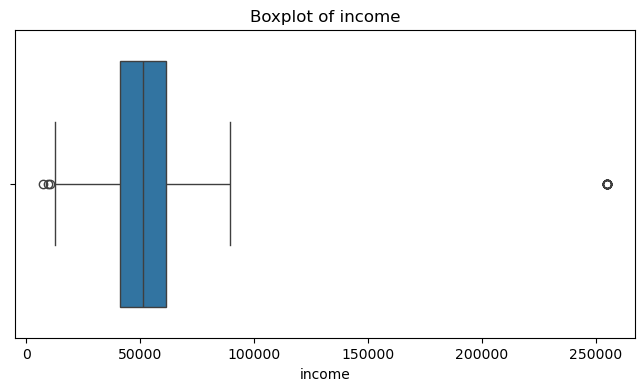

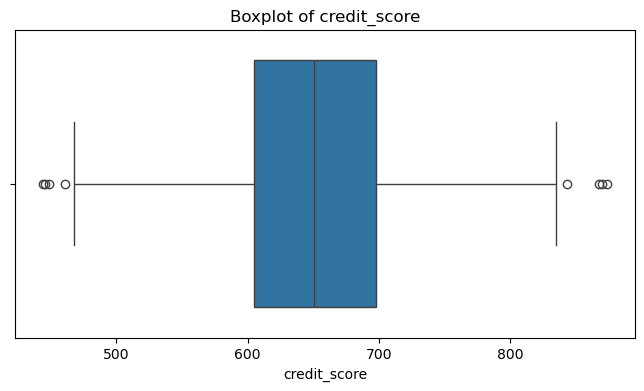

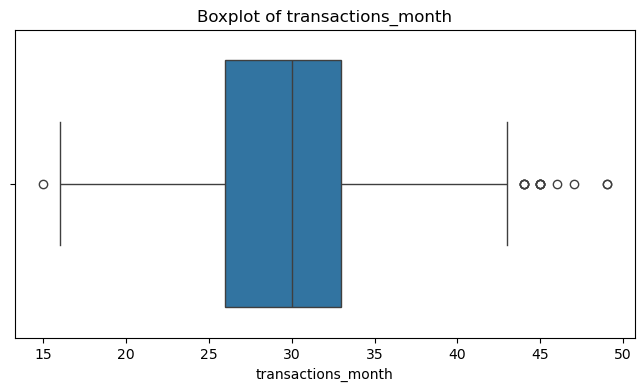

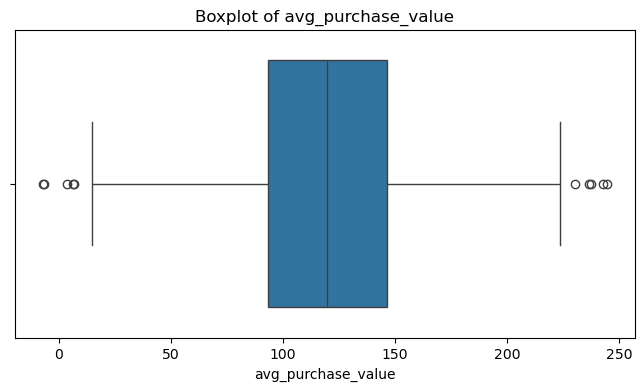

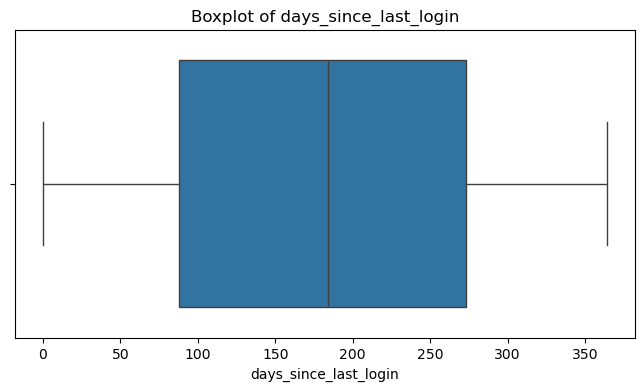

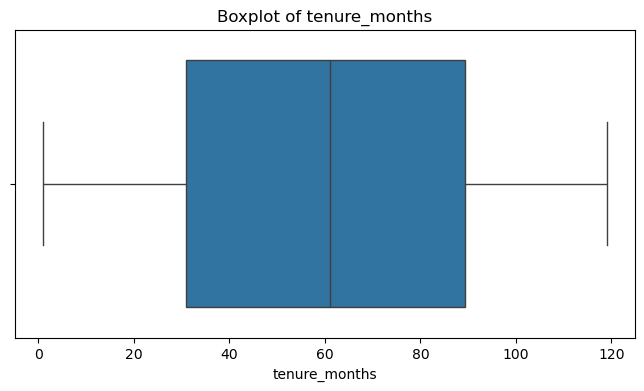

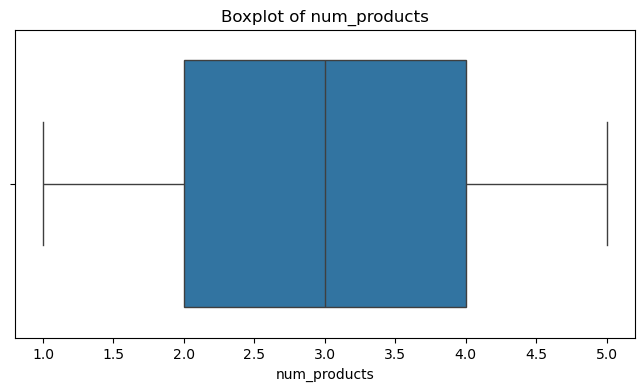

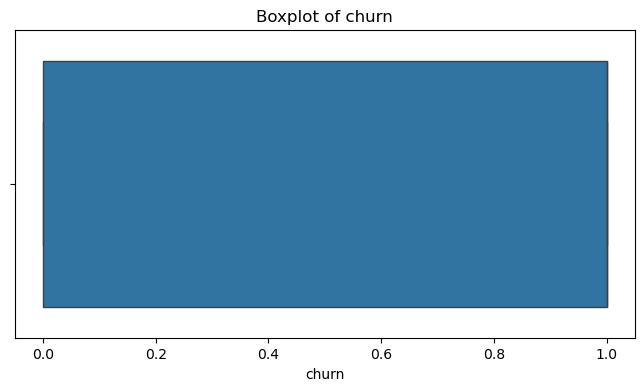

In [9]:
#check outliers in numerical columns
numerical_cols = c.select_dtypes(include=np.number).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=c[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [10]:
#check numerarical columns and categorical columns
numerical_cols = c.select_dtypes(include=np.number).columns
categorical_cols = c.select_dtypes(include='object').columns
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'churn'],
      dtype='object')
Categorical Columns: Index(['gender', 'region'], dtype='object')


In [11]:
c.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


In [12]:
# data preprocessing


In [13]:
#handle missing values in the dataset 
c.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [14]:
c['income'].value_counts()

income
254852.478291    20
53051.954538      1
39677.744822      1
51883.646802      1
47403.922636      1
                 ..
43317.462179      1
73693.582186      1
42157.099593      1
43697.197744      1
44407.502719      1
Name: count, Length: 932, dtype: int64

In [15]:
c['income'].median()
c['income'].mean()
c['income'].mode()[0]
print("Median:", c['income'].median())
print("Mean:", c['income'].mean())
print("Mode:", c['income'].mode()[0])


Median: 51298.8468120935
Mean: 55354.41751318089
Mode: 254852.4782908424


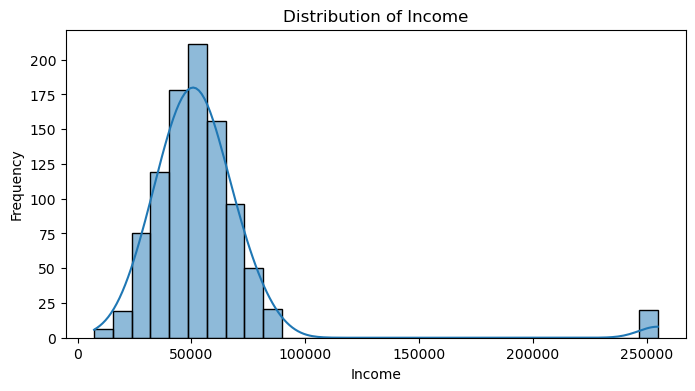

In [16]:
#distribution of income column
plt.figure(figsize=(8, 4))
sns.histplot(c['income'], bins=30, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [17]:
#find the median of the income column after removing outliers
median_income=round(c['income'].median())
median_income


51299

In [18]:
#print rounded median income of 6 digits
print("Rounded Median Income:", round(median_income, 7))




Rounded Median Income: 51299


In [19]:
c['income'].fillna(median_income, inplace=True)


C:\Users\ram\AppData\Local\Temp\ipykernel_18120\3621524685.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c['income'].fillna(median_income, inplace=True)


In [20]:
c.isnull().sum()

age                       0
income                    0
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

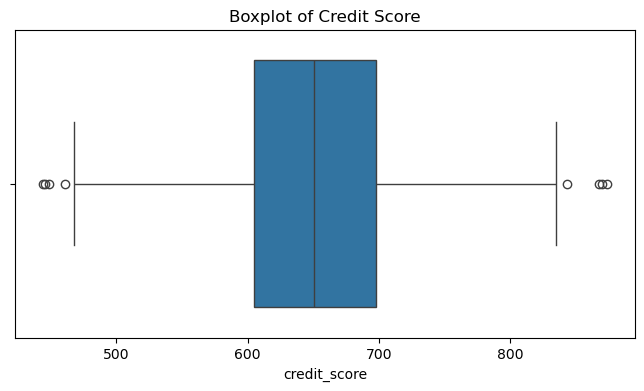

In [21]:
#check the ouuliers using boc plot for credit score column
plt.figure(figsize=(8, 4))
sns.boxplot(x=c['credit_score'])
plt.title('Boxplot of Credit Score')
plt.show()

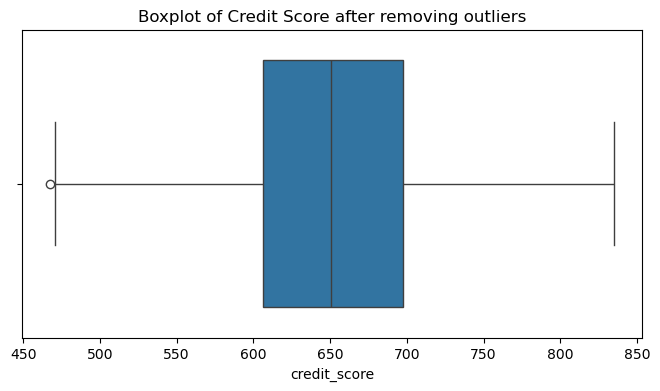

In [22]:
#remove outliers from credit score column using IQR method
Q1 = c['credit_score'].quantile(0.25)
Q3 = c['credit_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
c = c[(c['credit_score'] >= lower_bound) & (c['credit_score'] <= upper_bound)]
#check the ouuliers using boc plot for credit score column after removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=c['credit_score'])
plt.title('Boxplot of Credit Score after removing outliers')
plt.show()

In [23]:
#check mean and mode and median of credit score column after removing outliers
print("Median:", c['credit_score'].median())
print("Mean:", c['credit_score'].mean())
print("Mode:", c['credit_score'].mode()[0])


Median: 650.7467679262613
Mean: 651.3782068403109
Mode: 467.7050300361006


In [24]:
mean_credit_score = c['credit_score'].mean()
mean_credit_score

651.3782068403109

In [25]:
mean_credit_score = round(mean_credit_score,7)

In [26]:
c.credit_score.fillna(mean_credit_score, inplace=True)

C:\Users\ram\AppData\Local\Temp\ipykernel_18120\2195317938.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c.credit_score.fillna(mean_credit_score, inplace=True)
C:\Users\ram\AppData\Local\Temp\ipykernel_18120\2195317938.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c.credit_score.fillna(mean_credit_score, inplace=True)


In [27]:
c.isnull().sum()

age                       0
income                    0
credit_score              0
transactions_month        0
avg_purchase_value       46
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

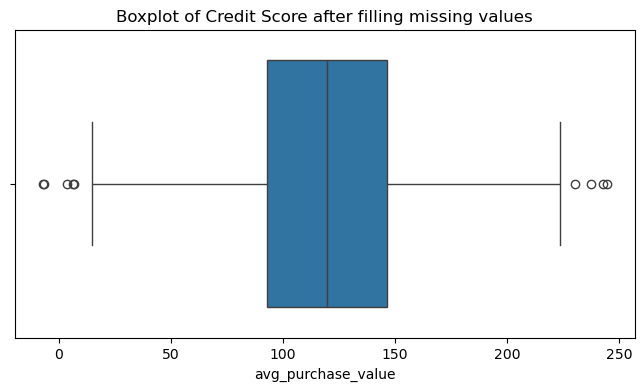

In [28]:
#box plot for credit score column after filling missing values
plt.figure(figsize=(8, 4))
sns.boxplot(x=c['avg_purchase_value'])
plt.title('Boxplot of Credit Score after filling missing values')
plt.show()


Text(0.5, 1.0, 'Boxplot of Avg Purchase Value after removing outliers')

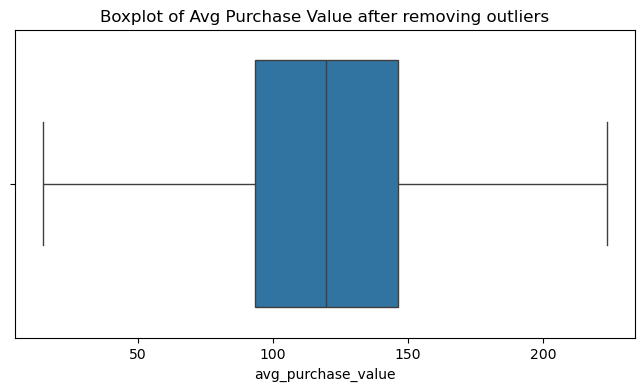

In [29]:
#remove outfliers from avg purchase value column using IQR method
Q1 = c['avg_purchase_value'].quantile(0.25)
Q3 = c['avg_purchase_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
c = c[(c['avg_purchase_value'] >= lower_bound) & (c['avg_purchase_value'] <= upper_bound)]
#check the ouuliers using boc plot for avg purchase value column after removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=c['avg_purchase_value'])
plt.title('Boxplot of Avg Purchase Value after removing outliers')


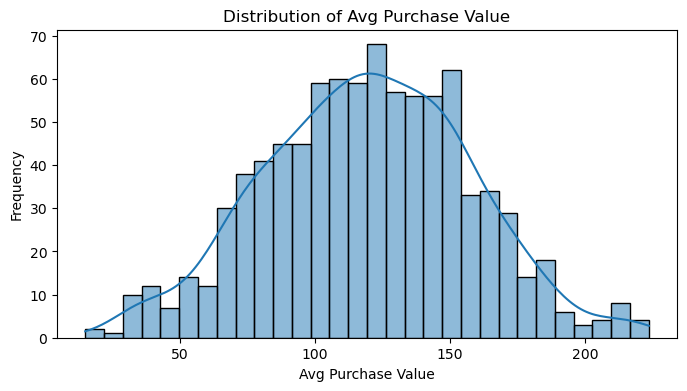

In [30]:
#find the distribution of avg purchase value column
plt.figure(figsize=(8, 4))
sns.histplot(c['avg_purchase_value'], bins=30, kde=True)
plt.title('Distribution of Avg Purchase Value')
plt.xlabel('Avg Purchase Value')
plt.ylabel('Frequency')
plt.show()

In [31]:
median_avg_purchase_value = c['avg_purchase_value'].median()

In [32]:
median_avg_purchase_value=round(median_avg_purchase_value,7)
median_avg_purchase_value

119.6754719

In [33]:
c['avg_purchase_value'].fillna(median_avg_purchase_value, inplace=True)

C:\Users\ram\AppData\Local\Temp\ipykernel_18120\2000543586.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c['avg_purchase_value'].fillna(median_avg_purchase_value, inplace=True)


In [34]:
c.isnull().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

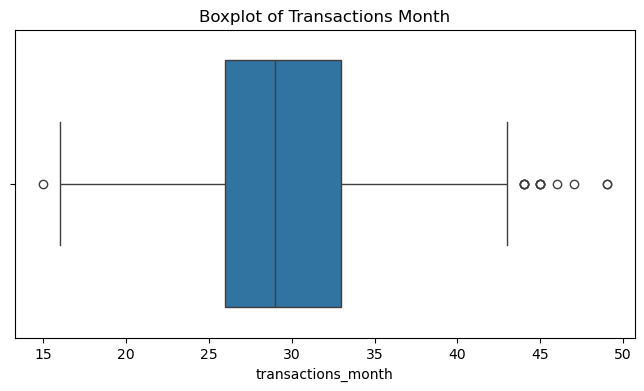

In [35]:
#find outliers in in transactions_month column
plt.figure(figsize=(8, 4))
sns.boxplot(x=c['transactions_month'])
plt.title('Boxplot of Transactions Month')
plt.show()

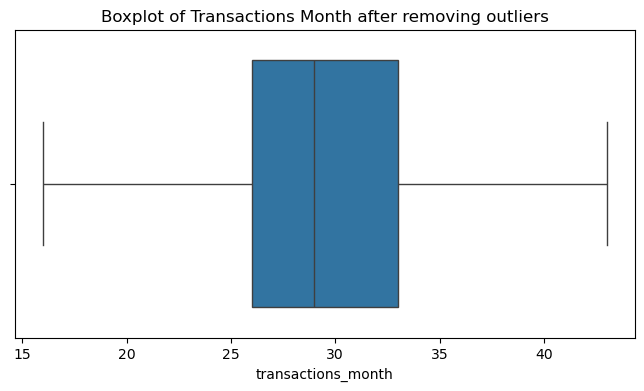

In [36]:
#remove outliers from credit score column using IQR method
Q1 = c['transactions_month'].quantile(0.25)
Q3 = c['transactions_month'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
c = c[(c['transactions_month'] >= lower_bound) & (c['transactions_month'] <= upper_bound)]
#check the ouuliers using boc plot for transactions_month column after removing outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=c['transactions_month'])
plt.title('Boxplot of Transactions Month after removing outliers')
plt.show()


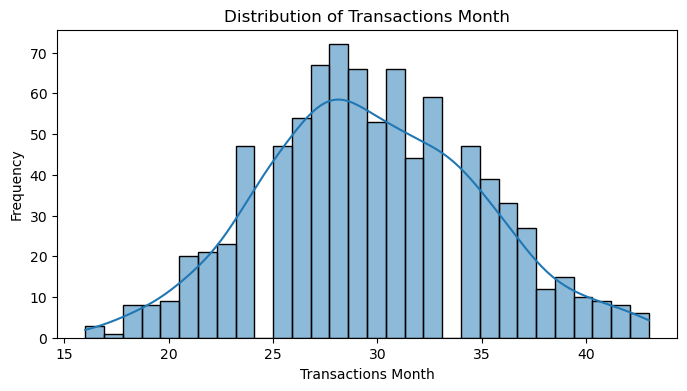

In [37]:
#check the distrubtuion of transactions_month column
plt.figure(figsize=(8, 4))
sns.histplot(c['transactions_month'], bins=30, kde=True)
plt.title('Distribution of Transactions Month')
plt.xlabel('Transactions Month')
plt.ylabel('Frequency')
plt.show()


In [38]:
#use median to fill missing values in transactions_month column
median_transactions_month = c['transactions_month'].median()
median_transactions_month=round(median_transactions_month,7)
median_transactions_month

29.0

In [39]:
#fillna for transactions_month column
c['transactions_month'].fillna(median_transactions_month, inplace=True)


C:\Users\ram\AppData\Local\Temp\ipykernel_18120\3755365069.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c['transactions_month'].fillna(median_transactions_month, inplace=True)


In [40]:
c.isnull().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

In [41]:
#check categdorical columns and numerical columns
numerical_cols = c.select_dtypes(include=np.number).columns
categorical_cols = c.select_dtypes(include='object').columns
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)



Numerical Columns: Index(['age', 'income', 'credit_score', 'transactions_month',
       'avg_purchase_value', 'days_since_last_login', 'tenure_months',
       'num_products', 'churn'],
      dtype='object')
Categorical Columns: Index(['gender', 'region'], dtype='object')


In [42]:
#check statistics summaryr
c.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000,874.000000
mean,43.974828,55381.572667,651.313467,29.683066,119.114577,181.370709,59.679634,3.135011,0.519451
std,14.974489,32324.128079,65.855740,5.212243,37.876244,104.837341,34.163684,1.409373,0.499908
min,18.000000,7271.860691,467.705030,16.000000,15.007318,0.000000,1.000000,1.000000,0.000000
25%,31.000000,41799.420230,604.987613,26.000000,93.277753,87.000000,31.000000,2.000000,0.000000
50%,44.000000,51299.000000,651.329909,29.000000,119.585761,182.500000,60.000000,3.000000,1.000000
75%,56.000000,60907.457206,697.810683,33.000000,146.206425,274.000000,88.750000,4.000000,1.000000
max,69.000000,254852.478291,835.104034,43.000000,223.516359,364.000000,119.000000,5.000000,1.000000


In [43]:
for col in categorical_cols:
    print(f"unique values in {col} column: {c[col].unique()}")

unique values in gender column: ['Male' 'Female']
unique values in region column: ['South' 'East' 'North' 'West']


In [44]:
c

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,51299.000000,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
5,25,51299.000000,526.743383,18,104.602284,286,37,4,Female,South,0
...,...,...,...,...,...,...,...,...,...,...,...
994,63,48185.777771,633.839354,26,129.585101,222,88,1,Male,South,0
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0


In [45]:
#chnage the female into 0 and male into 1 in gender use map function
c['gender'] = c['gender'].map({'Male': 0, 'Female': 1})
c.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,51299.000000,770.887470,29,84.828689,143,90,1,0,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,South,0
5,25,51299.000000,526.743383,18,104.602284,286,37,4,1,South,0


In [46]:
#change only boolean columns into 0 and 1 using map function
boolean_cols = c.select_dtypes(include='bool').columns
for col in boolean_cols:
    c[col] = c[col].map({True: 1, False: 0})

In [47]:
c.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,51299.000000,770.887470,29,84.828689,143,90,1,0,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,South,0
5,25,51299.000000,526.743383,18,104.602284,286,37,4,1,South,0


In [48]:
c.dtypes

age                        int64
income                   float64
credit_score             float64
transactions_month         int64
avg_purchase_value       float64
days_since_last_login      int64
tenure_months              int64
num_products               int64
gender                     int64
region                    object
churn                      int64
dtype: object

In [49]:
c=pd.get_dummies(c,columns=['region'])

In [50]:
c

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
0,56,51299.000000,770.887470,29,84.828689,143,90,1,0,1,False,False,True,False
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,1,True,False,False,False
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,1,False,True,False,False
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,0,False,False,True,False
5,25,51299.000000,526.743383,18,104.602284,286,37,4,1,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,63,48185.777771,633.839354,26,129.585101,222,88,1,0,0,False,False,True,False
995,60,56292.986659,751.728246,26,149.322171,120,93,4,0,0,False,False,False,True
996,64,36687.617333,556.297594,40,44.289513,172,3,4,0,1,False,False,True,False
997,62,43438.125495,698.504304,33,132.459634,3,52,2,0,0,True,False,False,False


In [51]:
for col in c.columns:
    if c[col].dtype=='bool':
        c[col]=c[col].map({True:1,False:0})
c

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
0,56,51299.000000,770.887470,29,84.828689,143,90,1,0,1,0,0,1,0
1,69,53051.954538,622.025467,41,133.943805,72,96,4,1,1,1,0,0,0
2,46,38654.738821,665.727931,36,114.993023,155,88,3,0,1,0,1,0,0
3,32,28666.194356,715.281358,29,153.875284,76,110,2,0,0,0,0,1,0
5,25,51299.000000,526.743383,18,104.602284,286,37,4,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,63,48185.777771,633.839354,26,129.585101,222,88,1,0,0,0,0,1,0
995,60,56292.986659,751.728246,26,149.322171,120,93,4,0,0,0,0,0,1
996,64,36687.617333,556.297594,40,44.289513,172,3,4,0,1,0,0,1,0
997,62,43438.125495,698.504304,33,132.459634,3,52,2,0,0,1,0,0,0


In [52]:
from  sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
numerical_cols=['income','credit_score','avg_purchase_value','transactions_month']
c[numerical_cols]=scaler.fit_transform(c[numerical_cols])
c



,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,churn,region_East,region_North,region_South,region_West
0,56,0.177830,0.825213,0.481481,0.334860,143,90,1,0,1,0,0,1,0
1,69,0.184910,0.420035,0.925926,0.570414,72,96,4,1,1,1,0,0,0
2,46,0.126758,0.538986,0.740741,0.479527,155,88,3,0,1,0,1,0,0
3,32,0.086414,0.673862,0.481481,0.666005,76,110,2,0,0,0,0,1,0
5,25,0.177830,0.160693,0.074074,0.429693,286,37,4,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,63,0.165255,0.452190,0.370370,0.549510,222,88,1,0,0,0,0,1,0
995,60,0.198001,0.773065,0.370370,0.644168,120,93,4,0,0,0,0,0,1
996,64,0.118813,0.241134,0.888889,0.140436,172,3,4,0,1,0,0,1,0
997,62,0.146079,0.628198,0.629630,0.563296,3,52,2,0,0,1,0,0,0


In [53]:
X=c.drop('churn', axis=1)
y=c['churn']

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
model=LogisticRegression()
model.fit(X_train, y_train)

c:\Users\ram\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [56]:
y_pred=model.predict(X_test)

In [57]:
print(y_pred)

[1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1 1 1 0 1 0 1 1 0 0 1 1 0 1 1
 1 1 1 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0
 0 1 1 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0
 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1
 0 1 1 0 1 0 1 0 1 1 0 1 1 1 1 0 1 0 0 0 1 0 0 1 1 1 1]


In [58]:
results=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
results

,Actual,Predicted
912,1,1
364,1,1
443,0,1
838,0,1
490,1,1
...,...,...
238,0,0
796,0,1
91,1,1
975,1,1


In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix: [[33 48]
 [32 62]]
Classification Report:               precision    recall  f1-score   support

           0       0.51      0.41      0.45        81
           1       0.56      0.66      0.61        94

    accuracy                           0.54       175
   macro avg       0.54      0.53      0.53       175
weighted avg       0.54      0.54      0.54       175

Accuracy Score: 0.5428571428571428
